# Movie-Ratings Analysis

In [1]:
import pandas as pd

-     read the datasets

In [2]:
tags=pd.read_csv(r"C:\Users\TharunMahendra\OneDrive\Desktop\NIT\DataSets\MovieRatings\tag.csv")
movies=pd.read_csv(r"C:\Users\TharunMahendra\OneDrive\Desktop\NIT\DataSets\MovieRatings\movie.csv")
ratings=pd.read_csv(r"C:\Users\TharunMahendra\OneDrive\Desktop\NIT\DataSets\MovieRatings\rating.csv")

In [3]:
tags.head()

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [6]:
print(tags.shape)
print(movies.shape)
print(ratings.shape)

(465564, 4)
(27278, 3)
(20000263, 4)


In [7]:
print(tags.columns)
print(movies.columns)
print(ratings.columns)

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


-     For current analysis, we will remove timestamp

In [8]:
del ratings['timestamp']
del tags['timestamp']

In [9]:
print(ratings.columns)
print(tags.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating'], dtype='object')
Index(['userId', 'movieId', 'tag'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')


## DataStructures

In [10]:
row=tags.iloc[0] #Purely integer-location based indexing for selection by position.
print(row)
print(' ')
print(type(row))

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object
 
<class 'pandas.core.series.Series'>


In [11]:
row.index

Index(['userId', 'movieId', 'tag'], dtype='object')

In [12]:
row["userId"]

18

In [13]:
'rating' in row

False

In [14]:
'movieId' in row

True

In [15]:
row.name

0

In [16]:
row=row.rename('FirstRow')
row

userId              18
movieId           4141
tag        Mark Waters
Name: FirstRow, dtype: object

In [17]:
row.name

'FirstRow'

## DataFrames

In [18]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [19]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [20]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [21]:
tags.iloc[[584,6958,0,1254,465563]]

,userId,movieId,tag
584,342,99114,Leonardo DiCaprio
6958,1741,3726,related:Rio Bravo(1958)
0,18,4141,Mark Waters
1254,505,79132,sci-fi
465563,138472,923,rise to power


In [22]:
row=tags[0:1]
print(row)
print(' ')
print(type(row))

   userId  movieId          tag
0      18     4141  Mark Waters
 
<class 'pandas.core.frame.DataFrame'>


## DescriptiveStatistics
-     let's see how ratings are distributed

In [23]:
ratings.head()

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [24]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [25]:
ratings.mean()

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [26]:
ratings['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [27]:
ratings['rating'].mean()

3.5255285642993797

In [28]:
ratings['rating'].min()

0.5

In [29]:
ratings['rating'].max()

5.0

In [30]:
ratings['rating'].mode()

0    4.0
Name: rating, dtype: float64

In [31]:
ratings['rating'].std()

1.051988919275684

In [32]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [33]:
filter=ratings['rating']>10
filter.any() #Return whether any element is True, potentially over an axis.

False

In [34]:
filter=ratings['rating']>0
filter.all() #Return whether all elements are True, potentially over an axis.

True

## DataCleaning
-     Handling missing values    

In [35]:
movies.isnull().any() #no null values

movieId    False
title      False
genres     False
dtype: bool

In [36]:
ratings.isnull().any() #no null values

userId     False
movieId    False
rating     False
dtype: bool

In [37]:
tags.isnull().any() #we have null values in tag

userId     False
movieId    False
tag         True
dtype: bool

In [38]:
tags.shape

(465564, 3)

-     we are going to drop null values

In [39]:
tags=tags.dropna() #Remove missing values.

In [40]:
tags.isnull().any()

userId     False
movieId    False
tag        False
dtype: bool

In [41]:
tags.shape

(465548, 3)

## DataVisualization

In [42]:
import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

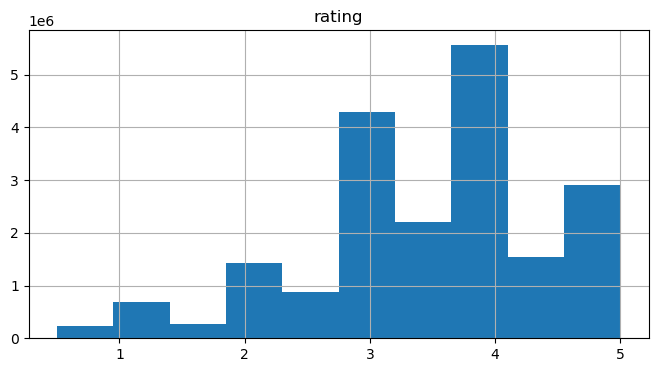

In [43]:
ratings.hist(column='rating',figsize=(8,4))

<Axes: >

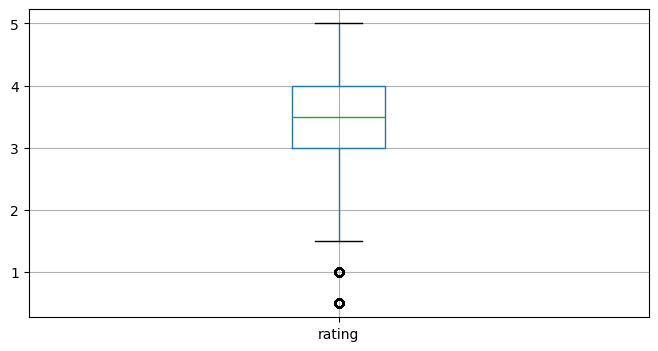

In [44]:
ratings.boxplot(column='rating',figsize=(8,4))

## Slicing-Out Columns

In [45]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: object

In [46]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [47]:
ratings[0:5]

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [48]:
ratings[-5:]

,userId,movieId,rating
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [49]:
tags_counts=tags['tag'].value_counts() #Return a Series containing the frequency of each distinct row in the Dataframe.

In [50]:
tags_counts[-5:]

tag
Paul Adelstein                   1
the wig                          1
killer fish                      1
genetically modified monsters    1
topless scene                    1
Name: count, dtype: int64

In [51]:
tags_counts[0:4]

tag
sci-fi             3384
based on a book    3281
atmospheric        2917
comedy             2779
Name: count, dtype: int64

<Axes: xlabel='tag'>

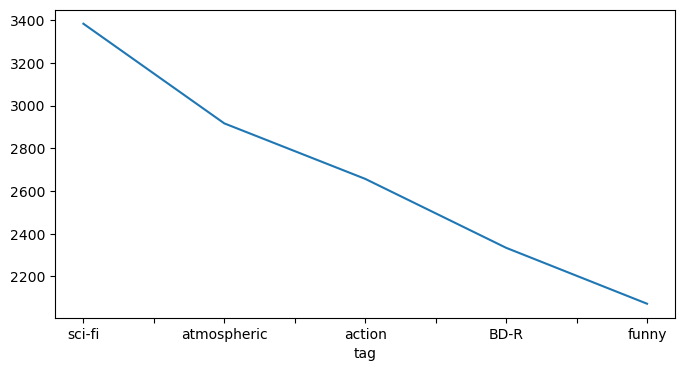

In [52]:
tags_counts[0:10:2].plot(kind='line',figsize=(8,4))

## Filtering Selected rows

In [53]:
highly_rated=ratings['rating']>=5.0

In [54]:
ratings[highly_rated][0:18467:1548]

,userId,movieId,rating
131,1,4993,5.0
7569,67,1304,5.0
19998,156,356,5.0
30325,241,27773,5.0
43008,331,280,5.0
54038,394,1089,5.0
65777,461,2268,5.0
74578,534,5952,5.0
84947,601,737,5.0
96258,670,296,5.0


In [55]:
is_action=movies['genres'].str.contains('Action')

In [56]:
movies[is_action][0:18:3]

,movieId,title,genres
5,6,Heat (1995),Action|Crime|Thriller
14,15,Cutthroat Island (1995),Action|Adventure|Romance
41,42,Dead Presidents (1995),Action|Crime|Drama
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller
75,76,Screamers (1995),Action|Sci-Fi|Thriller
88,89,Nick of Time (1995),Action|Thriller


## Group-By & Aggregate

In [57]:
ratings_count=ratings[['movieId','rating']].groupby('rating').count()

In [58]:
ratings_count

,movieId
rating,
0.5,239125
1.0,680732
1.5,279252
2.0,1430997
2.5,883398
3.0,4291193
3.5,2200156
4.0,5561926
4.5,1534824


In [59]:
average_rating=ratings[['movieId','rating']].groupby('movieId').mean()
average_rating.head()

,rating
movieId,
1,3.921240
2,3.211977
3,3.151040
4,2.861393
5,3.064592


In [60]:
movie_count = ratings[['movieId','rating']].groupby('movieId').count()
movie_count.head()

,rating
movieId,
1,49695
2,22243
3,12735
4,2756
5,12161


## Merge DataFrames

In [61]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [62]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [63]:
merged_data=movies.merge(tags,on='movieId',how='inner')
merged_data.head()

,movieId,title,genres,userId,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1644,Watched
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,computer animation
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Disney animated feature
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Pixar animation
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,TÃ©a Leoni does not star in this movie


-      Combine aggreagation, merging, and filters to get useful analytics

In [64]:
average_rating=ratings.groupby('movieId',as_index=False).mean()
average_rating.head()

,movieId,userId,rating
0,1,69282.396821,3.921240
1,2,69169.928202,3.211977
2,3,69072.079388,3.151040
3,4,69652.913280,2.861393
4,5,69113.475454,3.064592


In [65]:
del average_rating['userId']

In [66]:
average_rating.head()

,movieId,rating
0,1,3.921240
1,2,3.211977
2,3,3.151040
3,4,2.861393
4,5,3.064592


In [67]:
box_office=movies.merge(average_rating,on='movieId')

In [68]:
box_office.head()

,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.921240
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.211977
2,3,Grumpier Old Men (1995),Comedy|Romance,3.151040
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.861393
4,5,Father of the Bride Part II (1995),Comedy,3.064592


In [69]:
is_highly_rated=box_office['rating']>4.0
box_office[is_highly_rated].head()

,movieId,title,genres,rating
27,28,Persuasion (1995),Drama|Romance,4.057546
46,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,4.053493
49,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.334372
81,82,Antonia's Line (Antonia) (1995),Comedy|Drama,4.004925
108,110,Braveheart (1995),Action|Drama|War,4.042534


In [70]:
is_action=box_office['genres'].str.contains('Action')
box_office[is_action].head()

,movieId,title,genres,rating
5,6,Heat (1995),Action|Crime|Thriller,3.834930
8,9,Sudden Death (1995),Action,3.004924
9,10,GoldenEye (1995),Action|Adventure|Thriller,3.430029
14,15,Cutthroat Island (1995),Action|Adventure|Romance,2.721993
19,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller,2.880754


In [71]:
box_office[is_highly_rated & is_action].head()

,movieId,title,genres,rating
108,110,Braveheart (1995),Action|Drama|War,4.042534
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.190672
290,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller,4.050574
537,541,Blade Runner (1982),Action|Sci-Fi|Thriller,4.133706
891,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,4.233538


## Vectorized String Operations
-     splitting genres into multiple columns

In [72]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [73]:
movies_genres=movies['genres'].str.split('|',expand=True)

In [74]:
movies_genres.head()

,0,1,2,3,4,5,6,7,8,9
0,Adventure,Animation,Children,Comedy,Fantasy,None,None,None,None,None
1,Adventure,Children,Fantasy,None,None,None,None,None,None,None
2,Comedy,Romance,None,None,None,None,None,None,None,None
3,Comedy,Drama,Romance,None,None,None,None,None,None,None
4,Comedy,None,None,None,None,None,None,None,None,None


-     adding an new column iscomedy

In [75]:
movies_genres['isComedy']=movies['genres'].str.contains('Comedy')

In [76]:
movies_genres.head()

,0,1,2,3,4,5,6,7,8,9,isComedy
0,Adventure,Animation,Children,Comedy,Fantasy,None,None,None,None,None,True
1,Adventure,Children,Fantasy,None,None,None,None,None,None,None,False
2,Comedy,Romance,None,None,None,None,None,None,None,None,True
3,Comedy,Drama,Romance,None,None,None,None,None,None,None,True
4,Comedy,None,None,None,None,None,None,None,None,None,True


In [77]:
movies['year']=movies['title'].str.extract('.*\((.*)\).*', expand=True)

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
C:\Users\TharunMahendra\AppData\Local\Temp\ipykernel_9340\3553286959.py:1: SyntaxWarning: invalid escape sequence '\('
  movies['year']=movies['title'].str.extract('.*\((.*)\).*', expand=True)


In [78]:
movies[0:11865:1542]

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1542,1594,In the Company of Men (1997),Comedy|Drama,1997
3084,3171,Room at the Top (1959),Drama,1959
4626,4721,American Outlaws (2001),Action|Comedy|Western,2001
6168,6267,Assassination Tango (2002),Drama|Thriller,2002
7710,8232,I Love You Again (1940),Comedy|Drama,1940
9252,27255,"Wind Will Carry Us, The (Bad ma ra khahad bord...",Drama,1999
10794,43389,Numbskull Emptybrook in the Army (Uuno Turhapu...,Comedy,1984
